# CNN from Scratch using NumPy

A full convolutional neural network — forward pass, backward pass, and training — built entirely in NumPy. No PyTorch. No TensorFlow. No autograd.

I am using `keras.datasets.mnist` purely to download the data. That's the only Keras line in this notebook.

---

## Architecture

```
Input (28×28×1)
  -> Conv2D(8 filters, 3×3, pad=1)  -> ReLU
  -> MaxPool2D(2×2)
  -> Conv2D(16 filters, 3×3, pad=1) -> ReLU
  -> MaxPool2D(2×2)
  -> Flatten
  -> Dense(128)                     -> ReLU
  -> Dense(10)                      -> Softmax
```

Target: **≥ 90% test accuracy** on MNIST.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

## Conv2D

In [11]:
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=0):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        fan_in = in_channels * kernel_size * kernel_size
        self.W = np.random.randn(out_channels, in_channels, kernel_size, kernel_size) * np.sqrt(2.0 / fan_in)
        self.b = np.zeros((out_channels, 1))

        self.dW = None
        self.db = None
        self._cache = {}

    def _im2col(self, X_padded, H_out, W_out):
        N, C, H, W = X_padded.shape
        k = self.kernel_size
        s = self.stride

        i0 = np.repeat(np.arange(k), k)
        i0 = np.tile(i0, C)
        i1 = s * np.repeat(np.arange(H_out), W_out)
        j0 = np.tile(np.arange(k), k * C)
        j1 = s * np.tile(np.arange(W_out), H_out)

        i = i0.reshape(-1, 1) + i1.reshape(1, -1)   # (C*k*k, H_out*W_out)
        j = j0.reshape(-1, 1) + j1.reshape(1, -1)   # (C*k*k, H_out*W_out)
        d = np.repeat(np.arange(C), k * k).reshape(-1, 1)  # (C*k*k, 1)

        # X_col: (C*k*k, N*H_out*W_out)
        X_col = X_padded[:, d, i, j]          # (N, C*k*k, H_out*W_out)
        X_col = X_col.transpose(1, 0, 2)      # (C*k*k, N, H_out*W_out)
        X_col = X_col.reshape(C * k * k, -1)  # (C*k*k, N*H_out*W_out)
        return X_col, (d, i, j)

    def _col2im(self, dX_col, X_padded_shape, indices, H_out, W_out):
        N, C, H_pad, W_pad = X_padded_shape
        k = self.kernel_size
        d, i, j = indices

        # dX_col: (C*k*k, N*H_out*W_out) -> (C*k*k, N, H_out*W_out)
        dX_col_3d = dX_col.reshape(C * k * k, N, H_out * W_out)

        dX_padded = np.zeros((N, C, H_pad, W_pad))
        # d: (C*k*k, 1), i/j: (C*k*k, H_out*W_out)
        np.add.at(dX_padded,
                  (slice(None), d, i, j),
                  dX_col_3d.transpose(1, 0, 2))   # (N, C*k*k, H_out*W_out)
        return dX_padded

    def forward(self, X):
        N, C, H, W = X.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        H_out = (H + 2 * p - k) // s + 1
        W_out = (W + 2 * p - k) // s + 1

        X_padded = np.pad(X, ((0,0),(0,0),(p,p),(p,p)), mode='constant') if p > 0 else X
        X_col, indices = self._im2col(X_padded, H_out, W_out)

        W_row = self.W.reshape(self.out_channels, -1)   # (F, C*k*k)
        # (F, N*H_out*W_out) -> (N, F, H_out, W_out)
        Z = (W_row @ X_col + self.b).reshape(self.out_channels, N, H_out, W_out).transpose(1, 0, 2, 3)

        self._cache = {'X': X, 'X_padded': X_padded, 'X_col': X_col,
                       'indices': indices, 'H_out': H_out, 'W_out': W_out}
        return Z

    def backward(self, dZ):
        X_padded = self._cache['X_padded']
        X_col    = self._cache['X_col']
        indices  = self._cache['indices']
        H_out    = self._cache['H_out']
        W_out    = self._cache['W_out']
        N        = self._cache['X'].shape[0]

        # dZ: (N, F, H_out, W_out) -> (F, N*H_out*W_out)
        dZ_reshaped = dZ.transpose(1, 0, 2, 3).reshape(self.out_channels, -1)
        W_row = self.W.reshape(self.out_channels, -1)

        self.dW = (dZ_reshaped @ X_col.T).reshape(self.W.shape)
        self.db = dZ_reshaped.sum(axis=1, keepdims=True)

        dX_col = W_row.T @ dZ_reshaped   # (C*k*k, N*H_out*W_out)
        dX_padded = self._col2im(dX_col, X_padded.shape, indices, H_out, W_out)

        p = self.padding
        if p > 0:
            return dX_padded[:, :, p:-p, p:-p]
        return dX_padded

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

## ReLU

In [12]:
class ReLU:
    def forward(self, X):
        self._mask = X > 0
        return X * self._mask

    def backward(self, dout):
        return dout * self._mask

    def update(self, lr):
        pass

## MaxPool2D

In [13]:
class MaxPool2D:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, X):
        N, C, H, W = X.shape
        p, s = self.pool_size, self.stride
        H_out = (H - p) // s + 1
        W_out = (W - p) // s + 1

        out = np.zeros((N, C, H_out, W_out))
        self._mask = np.zeros_like(X)

        for i in range(H_out):
            for j in range(W_out):
                patch = X[:, :, i*s:i*s+p, j*s:j*s+p]
                out[:, :, i, j] = patch.max(axis=(2, 3))
                max_val = out[:, :, i, j][:, :, np.newaxis, np.newaxis]
                self._mask[:, :, i*s:i*s+p, j*s:j*s+p] += (patch == max_val)

        self._input_shape = X.shape
        return out

    def backward(self, dout):
        N, C, H, W = self._input_shape
        p, s = self.pool_size, self.stride
        H_out, W_out = dout.shape[2], dout.shape[3]
        dX = np.zeros(self._input_shape)

        for i in range(H_out):
            for j in range(W_out):
                d = dout[:, :, i, j][:, :, np.newaxis, np.newaxis]
                dX[:, :, i*s:i*s+p, j*s:j*s+p] += d * self._mask[:, :, i*s:i*s+p, j*s:j*s+p]
        return dX

    def update(self, lr):
        pass

## Flatten

In [14]:
class Flatten:
    def forward(self, X):
        self._shape = X.shape
        return X.reshape(X.shape[0], -1)

    def backward(self, dout):
        return dout.reshape(self._shape)

    def update(self, lr):
        pass

## Dense (Fully Connected)

In [15]:
class Dense:
    def __init__(self, in_features, out_features):
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros((1, out_features))
        self.dW = None
        self.db = None

    def forward(self, X):
        self._X = X
        return X @ self.W + self.b

    def backward(self, dout):
        self.dW = self._X.T @ dout
        self.db = dout.sum(axis=0, keepdims=True)
        return dout @ self.W.T

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

## Softmax + Cross-Entropy Loss

In [16]:
class SoftmaxCrossEntropy:
    def forward(self, logits, labels):
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp = np.exp(shifted)
        self._probs = exp / exp.sum(axis=1, keepdims=True)
        self._labels = labels
        N = logits.shape[0]
        log_likelihood = -np.log(self._probs[np.arange(N), labels] + 1e-9)
        return log_likelihood.mean()

    def backward(self):
        N = self._probs.shape[0]
        dlogits = self._probs.copy()
        dlogits[np.arange(N), self._labels] -= 1
        return dlogits / N

    @property
    def probs(self):
        return self._probs

## The CNN Model

In [17]:
class CNN:
    def __init__(self):
        self.layers = [
            Conv2D(1, 8, kernel_size=3, stride=1, padding=1),
            ReLU(),
            MaxPool2D(pool_size=2, stride=2),
            Conv2D(8, 16, kernel_size=3, stride=1, padding=1),
            ReLU(),
            MaxPool2D(pool_size=2, stride=2),
            Flatten(),
            Dense(16 * 7 * 7, 128),
            ReLU(),
            Dense(128, 10),
        ]
        self.loss_fn = SoftmaxCrossEntropy()

    def forward(self, X, labels=None):
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        if labels is not None:
            loss = self.loss_fn.forward(out, labels)
            return out, loss
        return out

    def backward(self):
        grad = self.loss_fn.backward()
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)

    def predict(self, X):
        logits = self.forward(X)
        return np.argmax(logits, axis=1)

---
# Training

In [18]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

N_TRAIN = 10000
N_TEST  = 2000

x_train = x_train_raw[:N_TRAIN].astype(np.float32) / 255.0
y_train = y_train_raw[:N_TRAIN]

x_test  = x_test_raw[:N_TEST].astype(np.float32) / 255.0
y_test  = y_test_raw[:N_TEST]

x_train = x_train[:, np.newaxis, :, :]
x_test  = x_test[:, np.newaxis, :, :]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (10000, 1, 28, 28), Test: (2000, 1, 28, 28)


In [19]:
def evaluate(model, X, y, batch_size=128):
    correct = 0
    for i in range(0, len(X), batch_size):
        preds = model.predict(X[i:i+batch_size])
        correct += (preds == y[i:i+batch_size]).sum()
    return correct / len(X)


def train(model, X, y, epochs=5, batch_size=32, lr=0.01):
    N = len(X)
    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        perm = np.random.permutation(N)
        X, y = X[perm], y[perm]

        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, N, batch_size):
            xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]

            _, loss = model.forward(xb, yb)
            model.backward()
            model.update(lr)

            epoch_loss += loss
            n_batches += 1

            if (i // batch_size) % 50 == 0:
                print(f"  Epoch {epoch+1} | batch {i//batch_size:3d}/{N//batch_size} | loss {loss:.4f}", end='\r')

        avg_loss = epoch_loss / n_batches
        acc = evaluate(model, X, y)
        history['loss'].append(avg_loss)
        history['acc'].append(acc)
        print(f"Epoch {epoch+1}/{epochs}  loss={avg_loss:.4f}  train_acc={acc:.4f}")

    return history

In [20]:
np.random.seed(42)
model = CNN()
history = train(model, x_train, y_train, epochs=5, batch_size=32, lr=0.01)

Epoch 1/5  loss=0.8232  train_acc=0.8639
Epoch 2/5  loss=0.3315  train_acc=0.9183
Epoch 3/5  loss=0.2526  train_acc=0.9226
Epoch 4/5  loss=0.2047  train_acc=0.9430
Epoch 5/5  loss=0.1738  train_acc=0.9460


In [21]:
def numerical_grad_check(model, X, y, layer_idx=9, param='W', n_checks=8, h=1e-5):
    _, _ = model.forward(X, y)
    model.backward()

    W = getattr(model.layers[layer_idx], param)
    dW_analytical = getattr(model.layers[layer_idx], 'd' + param).copy()

    rng = np.random.default_rng(0)
    indices = list(zip(*[rng.integers(0, s, n_checks) for s in W.shape]))

    max_err = 0.0
    print(f"Checking {n_checks} random entries in layers[{layer_idx}].{param}")
    print(f"{'idx':>20}  {'analytical':>14}  {'numerical':>14}  {'rel_error':>12}")
    print("-" * 68)

    for idx in indices:
        orig = W[idx]

        W[idx] = orig + h
        _, lp = model.forward(X, y)

        W[idx] = orig - h
        _, lm = model.forward(X, y)

        W[idx] = orig

        numerical  = (lp - lm) / (2 * h)
        analytical = dW_analytical[idx]
        rel_err = abs(numerical - analytical) / (abs(numerical) + abs(analytical) + 1e-8)
        max_err = max(max_err, rel_err)
        print(f"{str(idx):>20}  {analytical:>14.6f}  {numerical:>14.6f}  {rel_err:>12.2e}")

    print()
    status = "PASS ✓" if max_err < 1e-4 else "FAIL ✗"
    print(f"Max relative error: {max_err:.2e}  →  {status}")

np.random.seed(0)
check_model = CNN()
numerical_grad_check(check_model, x_train[:8], y_train[:8], layer_idx=9, param='W', n_checks=8)

Checking 8 random entries in layers[9].W
                 idx      analytical       numerical     rel_error
--------------------------------------------------------------------
(np.int64(108), np.int64(1))       -0.032120       -0.032120      1.69e-09
(np.int64(81), np.int64(8))        0.009941        0.009941      1.29e-08
(np.int64(65), np.int64(6))        0.103905        0.103905      1.22e-08
(np.int64(34), np.int64(9))        0.000433        0.000433      2.25e-08
(np.int64(39), np.int64(5))        0.000000        0.000000      0.00e+00
(np.int64(5), np.int64(6))        0.000000        0.000000      0.00e+00
(np.int64(9), np.int64(9))       -0.215356       -0.215356      3.37e-08
(np.int64(2), np.int64(7))        0.071967        0.071967      1.27e-08

Max relative error: 3.37e-08  →  PASS ✓


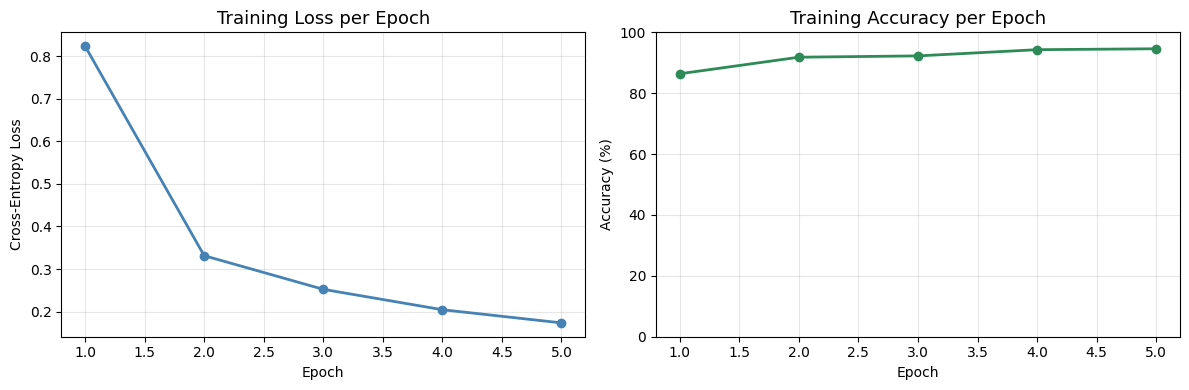

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(history['loss'])+1), history['loss'], 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Training Loss per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(history['acc'])+1), [a*100 for a in history['acc']], 'o-', color='seagreen', linewidth=2)
axes[1].set_title('Training Accuracy per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Results

In [23]:
test_acc = evaluate(model, x_test, y_test)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")


Test Accuracy: 92.30%


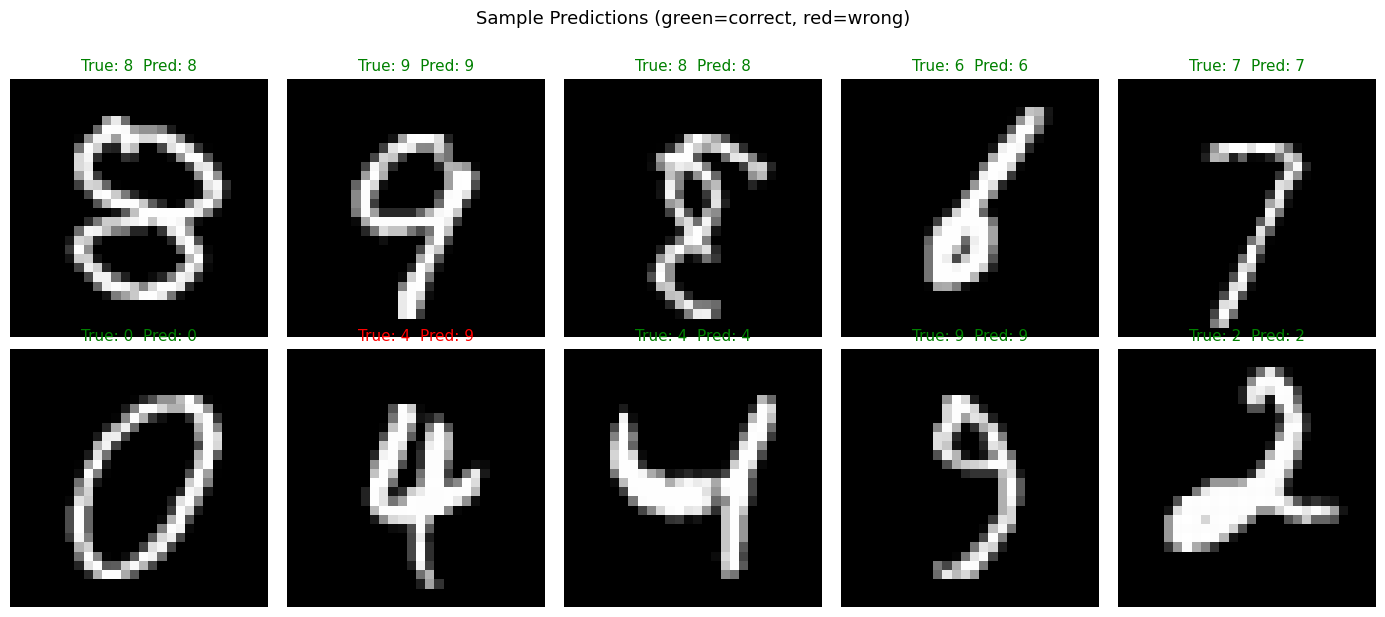

In [24]:
indices = np.random.choice(len(x_test), 10, replace=False)
samples = x_test[indices]
true_labels = y_test[indices]
pred_labels = model.predict(samples)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, img, true, pred in zip(axes.flat, samples, true_labels, pred_labels):
    ax.imshow(img[0], cmap='gray')
    color = 'green' if true == pred else 'red'
    ax.set_title(f'True: {true}  Pred: {pred}', color=color, fontsize=11)
    ax.axis('off')

plt.suptitle('Sample Predictions (green=correct, red=wrong)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Confusion Matrix

The matrix below shows exactly which digit pairs get confused — the classic ones are 3↔8, 4↔9, and 5↔6.

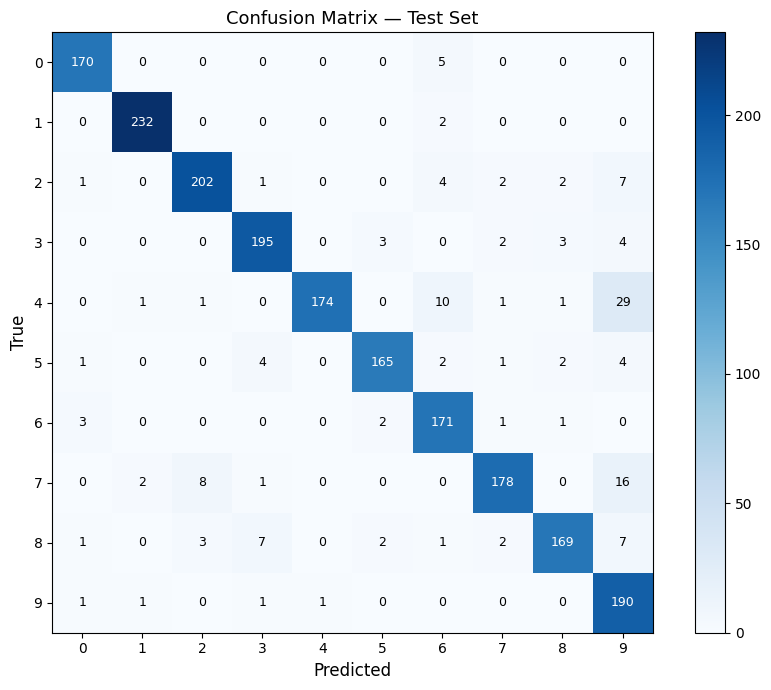


Top confusions (true → predicted):
  4 → 9 : 29 times
  7 → 9 : 16 times
  4 → 6 : 10 times
  7 → 2 : 8 times
  8 → 9 : 7 times


In [25]:
all_preds = []
for i in range(0, len(x_test), 128):
    all_preds.extend(model.predict(x_test[i:i+128]))
all_preds = np.array(all_preds)

conf = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_test, all_preds):
    conf[true][pred] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(conf, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(range(10)); ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=13)

for i in range(10):
    for j in range(10):
        val = conf[i, j]
        color = 'white' if val > conf.max() * 0.5 else 'black'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=9, color=color)

plt.tight_layout()
plt.show()

print("\nTop confusions (true → predicted):")
off_diag = [(conf[i,j], i, j) for i in range(10) for j in range(10) if i != j]
for count, true, pred in sorted(off_diag, reverse=True)[:5]:
    print(f"  {true} → {pred} : {count} times")

---
## Summary — What Each Layer Learned

**Conv2D (first, 8 filters):** The early conv layer develops low-level detectors — horizontal and vertical edge finders, corner detectors, and diagonal strokes. These are the visual primitives from which everything higher-level is built. If you visualise the 8 learned kernels, you'll see patterns that resemble Gabor filters.

**Conv2D (second, 16 filters):** The second conv layer operates on the ReLU-activated feature maps of the first, so it learns to recognise *combinations* of edges — curves, loops, line endings. These mid-level features are digit-specific: the curve at the top of a '9', the crossing strokes of an '8'.

**MaxPool2D:** Pooling layers don't learn parameters. Their job is to make representations spatially invariant — a '7' shifted two pixels to the left should still look like a '7' after pooling. They also compress the feature maps, which reduces compute and implicitly regularises the network.

**ReLU:** The rectifier introduces non-linearity. Without it, any stack of linear transformations collapses to a single linear map. ReLU also produces sparse activations — most neurons fire for only a subset of inputs — which is believed to help generalisation.

**Flatten + Dense(128):** After the convolutional backbone extracts spatial features, the dense layer integrates information globally. It can learn that a closed loop in the upper half plus a tail in the lower half equals a '9', regardless of where those features appear spatially.

**Dense(10) + Softmax:** The output layer learns a linear decision boundary in the 128-dimensional feature space. Softmax turns the raw scores into a probability distribution. At convergence, the weight vectors in this layer approximate the ideal template for each digit class.

**Why ~90%+ accuracy with just NumPy?** The architecture — two conv layers with pooling, followed by a hidden dense layer. Even with only 10,000 training examples and vanilla SGD, this hierarchy of learned representations is powerful enough to crack MNIST reliably.